In [3]:
import pandas as pd
import numpy as np


df=pd.read_csv("../data/Resumes_dataset.csv")
df.shape

(4000, 24)

In [2]:
df.describe()

,Experience_Years,Skill_Match_Percentage,ATS_Score
count,4000.000000,4000.000000,4000.000000
mean,3.374250,60.304367,51.310518
std,3.140884,22.107036,17.359977
min,0.000000,0.000000,0.000000
25%,0.750000,50.000000,41.067500
50%,2.500000,66.670000,52.665000
75%,5.250000,83.330000,63.470000
max,10.000000,100.000000,97.900000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Candidate_ID            4000 non-null   str    
 1   Job_Role                4000 non-null   str    
 2   Experience_Level        4000 non-null   str    
 3   Experience_Years        4000 non-null   int64  
 4   Education               4000 non-null   str    
 5   Skills                  4000 non-null   str    
 6   Technical_Skills        4000 non-null   str    
 7   Soft_Skills             4000 non-null   str    
 8   Certifications          2057 non-null   str    
 9   Projects                4000 non-null   str    
 10  Previous_Job_Title      4000 non-null   str    
 11  Industry                4000 non-null   str    
 12  Resume_Summary          4000 non-null   str    
 13  Resume_Text             4000 non-null   str    
 14  Target_Job_Title        4000 non-null   str    
 15

In [4]:
df.columns

Index(['Candidate_ID', 'Job_Role', 'Experience_Level', 'Experience_Years',
       'Education', 'Skills', 'Technical_Skills', 'Soft_Skills',
       'Certifications', 'Projects', 'Previous_Job_Title', 'Industry',
       'Resume_Summary', 'Resume_Text', 'Target_Job_Title', 'Job_Description',
       'Required_Skills', 'Preferred_Skills', 'Matched_Skills',
       'Missing_Skills', 'Skill_Match_Percentage', 'ATS_Score',
       'Recommendation', 'Recommendation_Reason'],
      dtype='str')

In [5]:
df["Job_Role"].unique()

<StringArray>
[        'Backend Developer',            'Cloud Engineer',
        'Frontend Developer',            'Data Scientist',
    'Database Administrator',              'Data Analyst',
           'DevOps Engineer',     'Cybersecurity Analyst',
               'QA Engineer',      'Full Stack Developer',
          'Python Developer',      'Mobile App Developer',
 'Machine Learning Engineer',         'Software Engineer',
        'Software Architect',          'Network Engineer',
      'System Administrator',            'UI/UX Designer',
             'Data Engineer',               'AI Engineer']
Length: 20, dtype: str

In [6]:
df.isnull().sum()

Candidate_ID                 0
Job_Role                     0
Experience_Level             0
Experience_Years             0
Education                    0
Skills                       0
Technical_Skills             0
Soft_Skills                  0
Certifications            1943
Projects                     0
Previous_Job_Title           0
Industry                     0
Resume_Summary               0
Resume_Text                  0
Target_Job_Title             0
Job_Description              0
Required_Skills              0
Preferred_Skills             0
Matched_Skills             137
Missing_Skills             148
Skill_Match_Percentage       0
ATS_Score                    0
Recommendation               0
Recommendation_Reason        0
dtype: int64

In [7]:
df["Job_Role"].value_counts()

Job_Role
Backend Developer            200
Cloud Engineer               200
Frontend Developer           200
Data Scientist               200
Database Administrator       200
Data Analyst                 200
DevOps Engineer              200
Cybersecurity Analyst        200
QA Engineer                  200
Full Stack Developer         200
Python Developer             200
Mobile App Developer         200
Machine Learning Engineer    200
Software Engineer            200
Software Architect           200
Network Engineer             200
System Administrator         200
UI/UX Designer               200
Data Engineer                200
AI Engineer                  200
Name: count, dtype: int64

In [8]:
X=df["Resume_Text"]
y=df["Job_Role"]

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", len(X_train))
print("Testing:", len(X_test))

Training: 3200
Testing: 800


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    max_features=10000,
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (3200, 2855)
Testing TF-IDF shape: (800, 2855)


In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=2000,
    C=2.0
)

model.fit(X_train_tfidf, y_train)

print("Model training completed.")

Model training completed.


In [13]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:10])

['System Administrator' 'Data Scientist' 'Database Administrator'
 'Cybersecurity Analyst' 'Software Architect' 'Network Engineer'
 'Backend Developer' 'Data Scientist' 'QA Engineer' 'AI Engineer']


In [14]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
                           precision    recall  f1-score   support

              AI Engineer       1.00      1.00      1.00        40
        Backend Developer       1.00      1.00      1.00        40
           Cloud Engineer       1.00      1.00      1.00        40
    Cybersecurity Analyst       1.00      1.00      1.00        40
             Data Analyst       1.00      1.00      1.00        40
            Data Engineer       1.00      1.00      1.00        40
           Data Scientist       1.00      1.00      1.00        40
   Database Administrator       1.00      1.00      1.00        40
          DevOps Engineer       1.00      1.00      1.00        40
       Frontend Developer       1.00      1.00      1.00        40
     Full Stack Developer       1.00      1.00      1.00        40
Machine Learning Engineer       1.00      1.00      1.00        40
     Mobile App Developer       1.00      1.00      1.00        40
         Network Engine

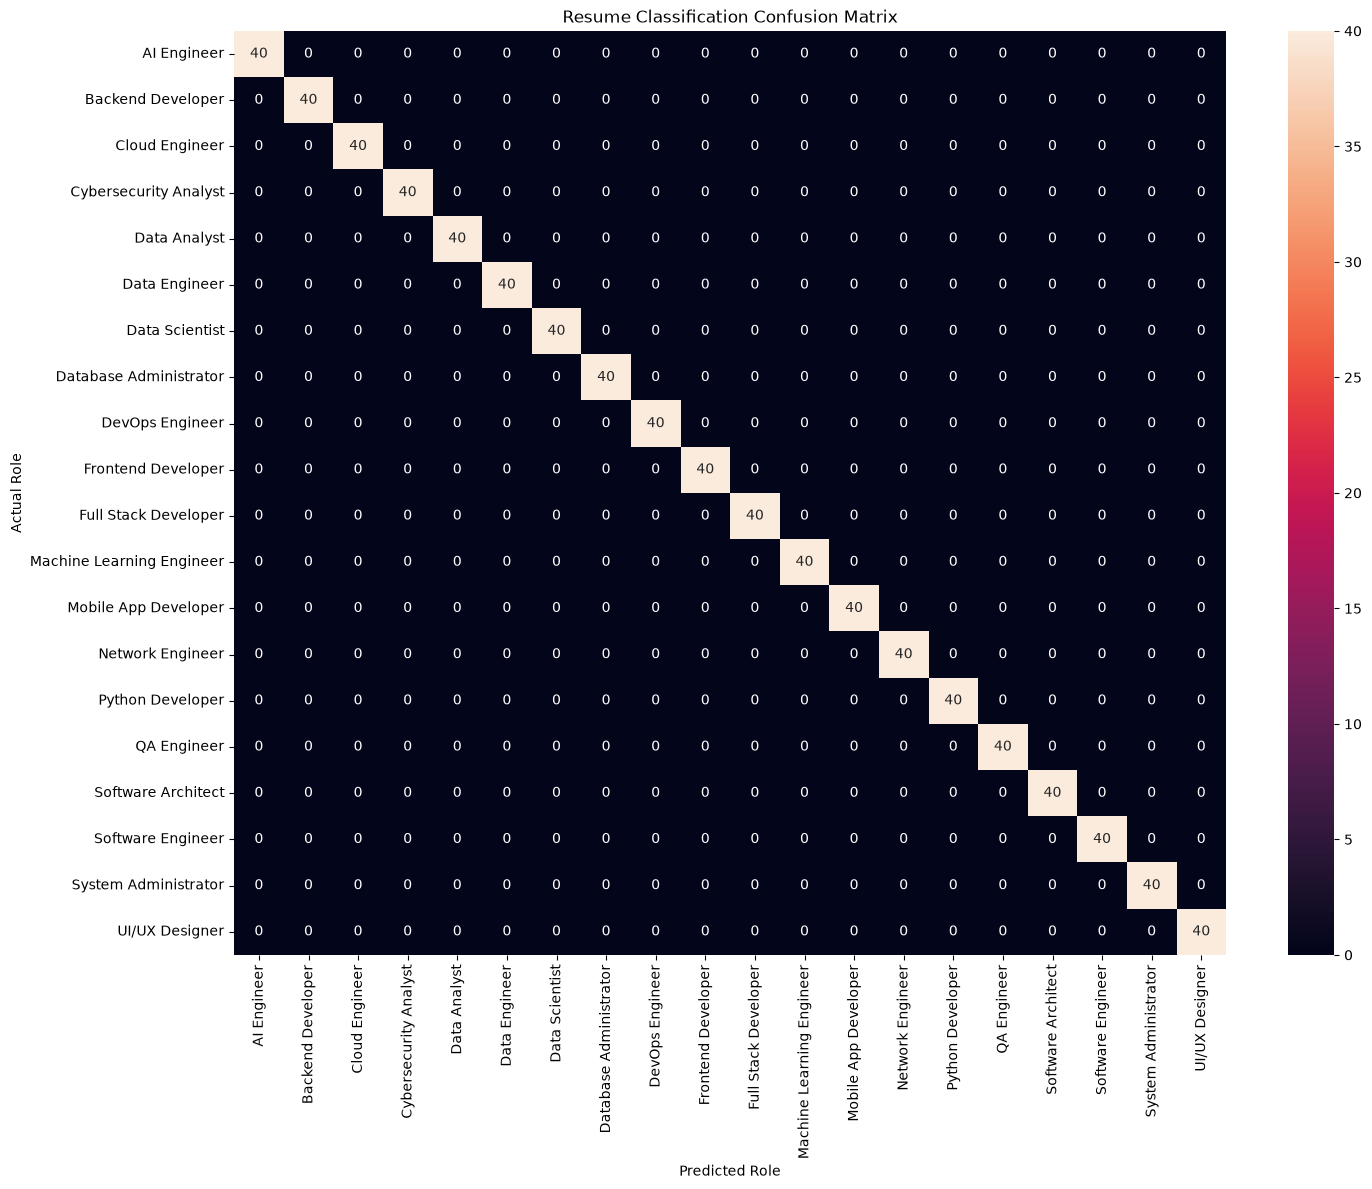

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(16, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted Role")
plt.ylabel("Actual Role")
plt.title("Resume Classification Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [17]:
new_resume = """
Python developer with 3 years of experience building REST APIs using
Django and FastAPI. Experienced with PostgreSQL, Docker, Git and
microservices. Developed backend services for an e-commerce platform.
"""

new_resume_tfidf = tfidf.transform([new_resume])

prediction = model.predict(new_resume_tfidf)

print("Predicted Job Role:", prediction[0])

Predicted Job Role: Python Developer


In [18]:
probabilities = model.predict_proba(new_resume_tfidf)[0]

results = pd.DataFrame({
    "Job_Role": model.classes_,
    "Probability": probabilities
})

results = results.sort_values(
    "Probability",
    ascending=False
)

print(results.head(5))

              Job_Role  Probability
14    Python Developer     0.812565
1    Backend Developer     0.064455
16  Software Architect     0.014322
17   Software Engineer     0.010251
9   Frontend Developer     0.009906


In [19]:
import joblib

joblib.dump(model, "resume_classifier.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model saved successfully.")

Model saved successfully.


In [20]:
import joblib

# Load the saved model
model = joblib.load("resume_classifier.pkl")

# Load the TF-IDF vectorizer
tfidf = joblib.load("tfidf_vectorizer.pkl")

print("Model loaded successfully!")
print("Vectorizer loaded successfully!")

Model loaded successfully!
Vectorizer loaded successfully!


In [21]:
new_resume = """
Python developer with 3 years of experience building REST APIs
using Django and FastAPI. Experienced with PostgreSQL, Docker,
Git and backend application development. Developed scalable
backend services for an e-commerce application.
"""

# Convert resume into TF-IDF features
new_resume_tfidf = tfidf.transform([new_resume])

# Predict job role
prediction = model.predict(new_resume_tfidf)

print("Predicted Job Role:", prediction[0])

Predicted Job Role: Python Developer
